# 05 - Evaluation
Loads the best checkpoint and runs full evaluation on the test set.

**What this notebook produces:**
- Overall accuracy, precision, recall, F1
- Per-class breakdown of all metrics (3 business classes: cedula / passport / unknown)
- Confusion matrix
- ROC-AUC (one-vs-rest, multiclass)
- Confidence score distribution per class
- Visual grid of wrong predictions (configurable count)

> **Note on class merging:** The model was trained with 4 internal classes (`id_new`, `id_old`, `passport`, `unknown`).
> At evaluation time, `id_new` and `id_old` probabilities are **summed** into a single `cedula` class,
> matching the 3-class spec output: `cedula | pasaporte | desconocido`.

In [213]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import timm
from pathlib import Path
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
)
from sklearn.preprocessing import label_binarize
import sys

In [214]:
GLOBAL_PATH = str(Path.cwd().parent.parent / "global")
if GLOBAL_PATH not in sys.path:
    sys.path.append(GLOBAL_PATH)
%reload_ext autoreload
%autoreload 2
import config
import utils

In [215]:
N_ERRORS_TO_SHOW = 12
print(f"Device : {config.DEVICE} - {config.DEVICE_NAME}")
print(f"Best Model : {config.BEST_MODEL}")
print(f"Results dir : {config.RESULTS_DIR}")
print(f"Errors to show  : {N_ERRORS_TO_SHOW}")

Device : cuda - NVIDIA GeForce RTX 3070
Best Model : D:\Aprender\Projects\ecuadorian-id-classifier\best_model.pth
Results dir : D:\Aprender\Projects\ecuadorian-id-classifier\results
Errors to show  : 12


In [216]:
# Internal model classes (as trained)
# id_new=0, id_old=1, passport=2, unknown=3

# Business output classes (as per spec)
MERGED_CLASS_NAMES = ["cedula", "pasaporte", "desconocido"]
MERGED_NUM_CLASSES = len(MERGED_CLASS_NAMES)

# Ground-truth label remap: collapse id_new + id_old → cedula
# id_new(0)->cedula(0), id_old(1)->cedula(0), passport(2)->pasaporte(1), unknown(3)->desconocido(2)
LABEL_REMAP = {0: 0, 1: 0, 2: 1, 3: 2}


def merge_id_classes(probs: np.ndarray) -> np.ndarray:
    """
    Collapses 4-class model probabilities into 3 business classes.
    cedula_prob      = id_new_prob + id_old_prob
    pasaporte_prob   = passport_prob  (unchanged)
    desconocido_prob = unknown_prob   (unchanged)

    Args:
        probs: np.ndarray of shape (N, 4)
    Returns:
        np.ndarray of shape (N, 3), rows still sum to 1
    """
    cedula      = probs[:, 0] + probs[:, 1]  # merge id_new + id_old
    pasaporte   = probs[:, 2]
    desconocido = probs[:, 3]
    return np.stack([cedula, pasaporte, desconocido], axis=1)


def remap_labels(labels_raw: np.ndarray) -> np.ndarray:
    """Remaps raw 4-class ground-truth labels to 3-class business labels."""
    return np.array([LABEL_REMAP[l] for l in labels_raw])


print("Class mapping:")
print("  Model output  →  Business class")
for raw, merged in LABEL_REMAP.items():
    print(f"  {config.CLASS_NAMES[raw]:10s} ({raw})  →  {MERGED_CLASS_NAMES[merged]} ({merged})")

Class mapping:
  Model output  →  Business class
  id_new     (0)  →  cedula (0)
  id_old     (1)  →  cedula (0)
  passport   (2)  →  pasaporte (1)
  unknown    (3)  →  desconocido (2)


In [217]:
assert config.BEST_MODEL.exists(), f"Checkpoint not found: {config.BEST_MODEL}\nRun notebook 04 first."

checkpoint = torch.load(config.BEST_MODEL, map_location=config.DEVICE)

model = timm.create_model(
    checkpoint["model_name"],
    pretrained=False,
    num_classes=checkpoint["num_classes"],  # 4 — original training classes
)
model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(config.DEVICE)
model.eval()

print(f"Model    : {checkpoint['model_name']}")
print(f"Device   : {config.DEVICE}")
print(f"Internal classes ({checkpoint['num_classes']}): {checkpoint['class_names']}")
print(f"Business classes ({MERGED_NUM_CLASSES}): {MERGED_CLASS_NAMES}")
print(f"Best val loss: {checkpoint['best_val_loss']:.4f}")

Model    : efficientnet_b0
Device   : cuda
Internal classes (4): ['id_new', 'id_old', 'passport', 'unknown']
Business classes (3): ['cedula', 'pasaporte', 'desconocido']
Best val loss: 0.8432


In [218]:
test_transforms = utils.get_transforms(is_train=False)
test_dataset    = utils.EcuadorianDocumentsDataset(
    config.TEST_DIR, config.CLASSES, transform=test_transforms
)
test_loader = DataLoader(
    test_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    pin_memory=(config.DEVICE.type == "cuda"),
)

print(f"Test samples : {len(test_dataset)}")
print(f"Test batches : {len(test_loader)}")
print(f"Class counts : {test_dataset.class_counts()}")

Test samples : 43
Test batches : 3
Class counts : {'id_new': 7, 'id_old': 7, 'passport': 8, 'unknown': 21}


In [219]:
all_probs     = []  # raw 4-class softmax probabilities
all_labels_raw  = []  # original 4-class ground truth
all_image_paths = []  # for the wrong-prediction grid

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(config.DEVICE)
        logits = model(images)
        probs  = F.softmax(logits, dim=1).cpu().numpy()
        all_probs.extend(probs)
        all_labels_raw.extend(labels.numpy())

# Store paths in the same order as the dataloader (shuffle=False)
all_image_paths = [str(p) for p, _ in test_dataset.samples]

all_probs    = np.array(all_probs)     # (N, 4)
all_labels_raw = np.array(all_labels_raw)  # (N,)

# ── Merge to 3 business classes ──────────────────────────────────────────────
merged_probs   = merge_id_classes(all_probs)       # (N, 3)
merged_preds   = np.argmax(merged_probs, axis=1)       # (N,)
merged_labels  = remap_labels(all_labels_raw)         # (N,)
merged_confs   = merged_probs.max(axis=1)              # (N,) confidence of top class

print(f"Inference complete. Samples evaluated: {len(merged_labels)}")

Inference complete. Samples evaluated: 43


In [220]:
overall_acc = (merged_preds == merged_labels).mean()
print(f"Overall Accuracy : {overall_acc:.4f} ({overall_acc*100:.2f}%)")
print()
print(classification_report(
    merged_labels,
    merged_preds,
    target_names=MERGED_CLASS_NAMES,
    digits=4,
))

Overall Accuracy : 0.7442 (74.42%)

              precision    recall  f1-score   support

      cedula     0.6471    0.7857    0.7097        14
   pasaporte     0.6364    0.8750    0.7368         8
 desconocido     0.9333    0.6667    0.7778        21

    accuracy                         0.7442        43
   macro avg     0.7389    0.7758    0.7414        43
weighted avg     0.7849    0.7442    0.7480        43



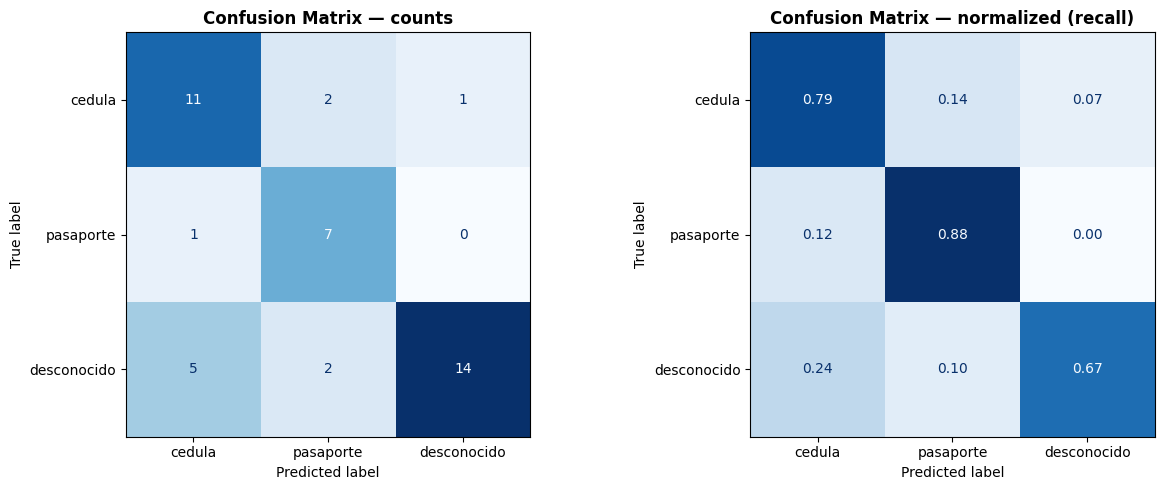

In [221]:
cm = confusion_matrix(merged_labels, merged_preds)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Raw counts
ConfusionMatrixDisplay(cm, display_labels=MERGED_CLASS_NAMES).plot(
    ax=axes[0], colorbar=False, cmap="Blues"
)
axes[0].set_title("Confusion Matrix — counts", fontweight="bold")

# Normalized (row = true class)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
ConfusionMatrixDisplay(cm_norm, display_labels=MERGED_CLASS_NAMES).plot(
    ax=axes[1], colorbar=False, cmap="Blues", values_format=".2f"
)
axes[1].set_title("Confusion Matrix — normalized (recall)", fontweight="bold")

plt.tight_layout()
plt.show()

Macro ROC-AUC (OvR): 0.9328


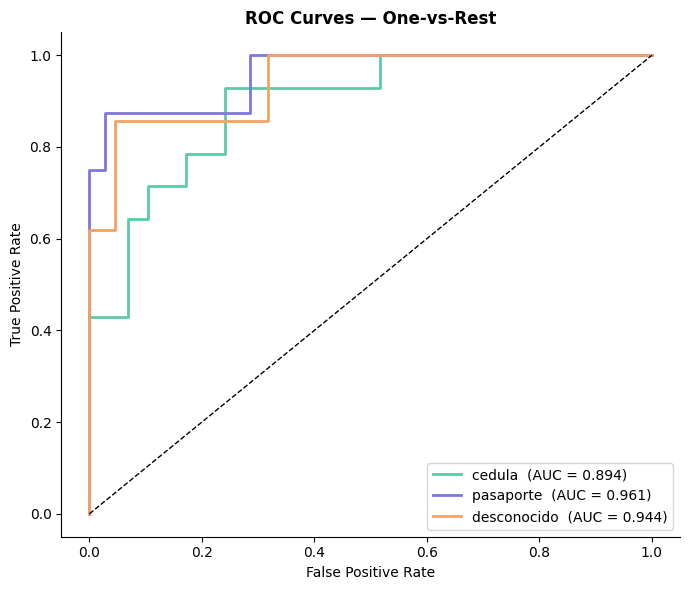

In [222]:
y_bin    = label_binarize(merged_labels, classes=list(range(MERGED_NUM_CLASSES)))
roc_auc  = roc_auc_score(y_bin, merged_probs, multi_class="ovr", average="macro")
print(f"Macro ROC-AUC (OvR): {roc_auc:.4f}")

COLORS = ["#5DCAA5", "#7F77DD", "#F4A261"]

fig, ax = plt.subplots(figsize=(7, 6))
for i, (cls_name, color) in enumerate(zip(MERGED_CLASS_NAMES, COLORS)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], merged_probs[:, i])
    auc_i = roc_auc_score(y_bin[:, i], merged_probs[:, i])
    ax.plot(fpr, tpr, label=f"{cls_name}  (AUC = {auc_i:.3f})", color=color, lw=2)

ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — One-vs-Rest", fontweight="bold")
ax.legend(loc="lower right")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

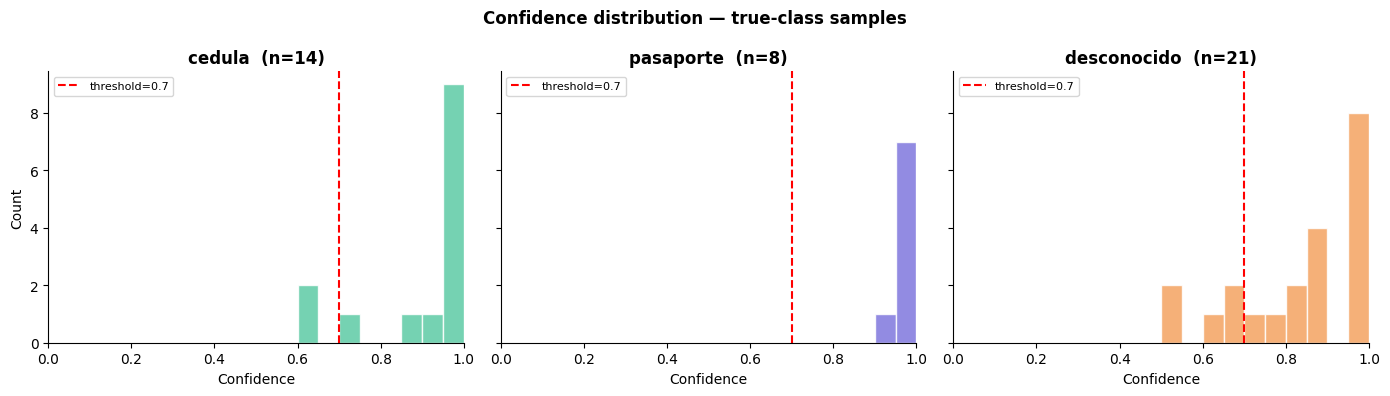

In [223]:
fig, axes = plt.subplots(1, MERGED_NUM_CLASSES, figsize=(14, 4), sharey=True)

for i, (cls_name, color, ax) in enumerate(zip(MERGED_CLASS_NAMES, COLORS, axes)):
    # Confidence of the predicted class, filtered to samples whose TRUE label is cls_name
    mask   = merged_labels == i
    confs  = merged_confs[mask]
    n      = mask.sum()

    ax.hist(confs, bins=20, range=(0, 1), color=color, edgecolor="white", alpha=0.85)
    ax.axvline(config.CONFIDENCE_THRESHOLD, color="red", linestyle="--", lw=1.5, label=f"threshold={config.CONFIDENCE_THRESHOLD}")
    ax.set_title(f"{cls_name}  (n={n})", fontweight="bold")
    ax.set_xlabel("Confidence")
    ax.set_xlim(0, 1)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(fontsize=8)

axes[0].set_ylabel("Count")
fig.suptitle("Confidence distribution — true-class samples", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

Wrong predictions: 11 / 43  (25.6%)


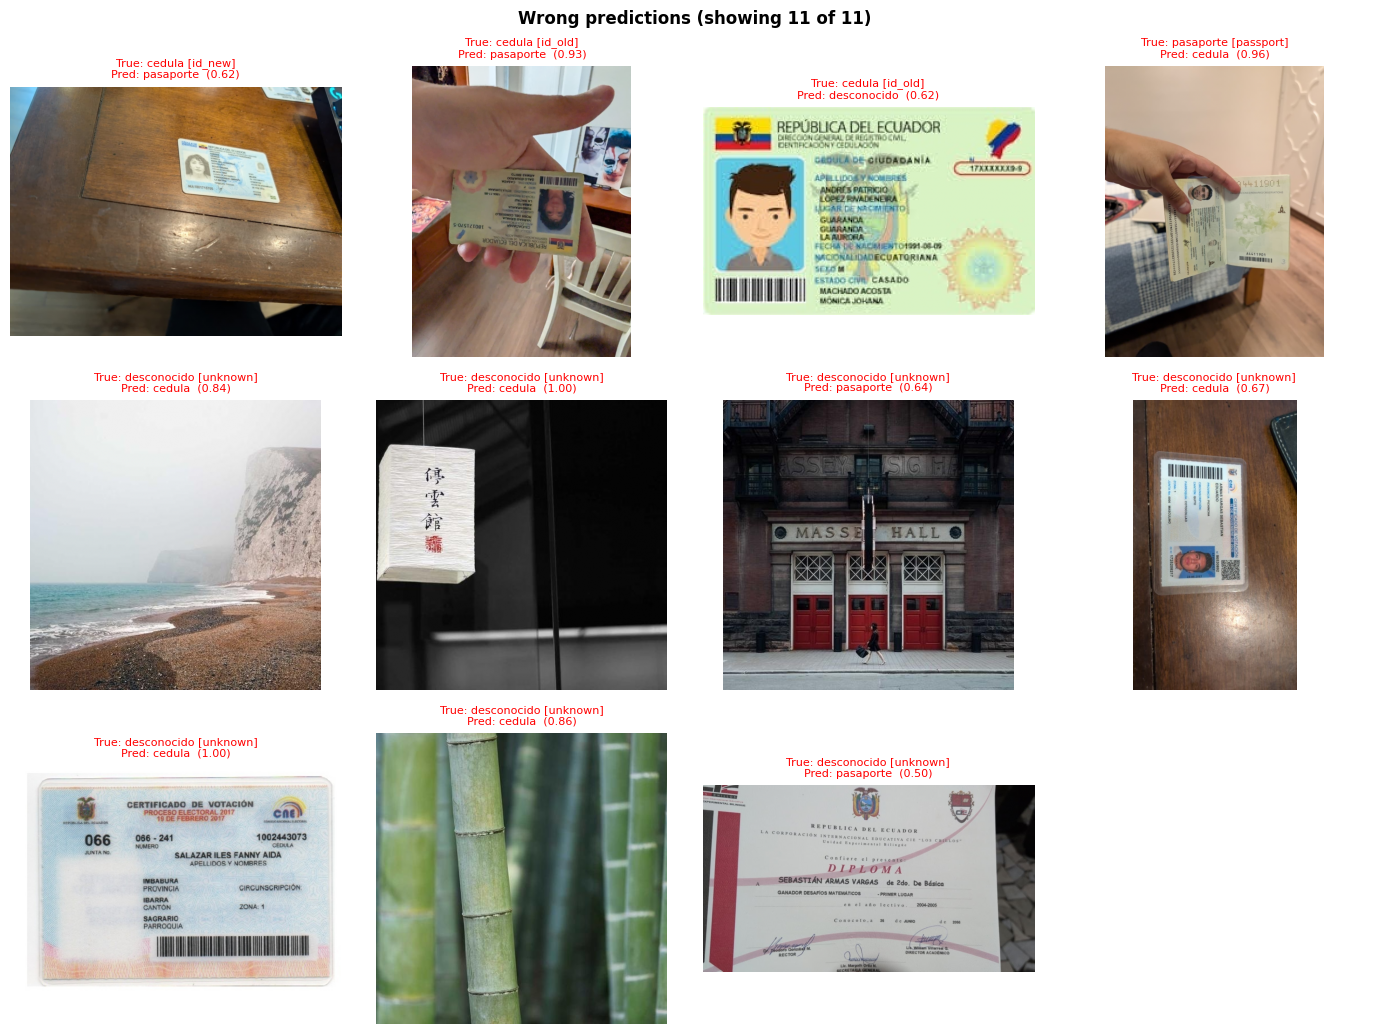

In [224]:
MAX_WRONG = 12  # change to show more or fewer thumbnails

mean_t = np.array(config.IMAGENET_MEAN).reshape(1, 1, 3)
std_t  = np.array(config.IMAGENET_STD).reshape(1, 1, 3)

wrong_idx = np.where(merged_preds != merged_labels)[0]
print(f"Wrong predictions: {len(wrong_idx)} / {len(merged_labels)}  ({len(wrong_idx)/len(merged_labels)*100:.1f}%)")

show_idx = wrong_idx[:MAX_WRONG]
ncols    = 4
nrows    = int(np.ceil(len(show_idx) / ncols))

if len(show_idx) == 0:
    print("No wrong predictions — perfect test set!")
else:
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.5 * nrows))
    axes_flat = np.array(axes).flatten()

    for i, idx in enumerate(show_idx):
        img = np.array(Image.open(all_image_paths[idx]).convert("RGB")).astype(float) / 255.0
        img = img.clip(0, 1)

        true_name = MERGED_CLASS_NAMES[merged_labels[idx]]
        pred_name = MERGED_CLASS_NAMES[merged_preds[idx]]
        conf      = merged_confs[idx]
        # Also note what the raw 4-class true label was
        raw_name  = config.CLASS_NAMES[all_labels_raw[idx]]

        axes_flat[i].imshow(img)
        axes_flat[i].set_title(
            f"True: {true_name} [{raw_name}]\nPred: {pred_name}  ({conf:.2f})",
            fontsize=8, color="red"
        )
        axes_flat[i].axis("off")

    for j in range(len(show_idx), len(axes_flat)):
        axes_flat[j].axis("off")

    fig.suptitle(f"Wrong predictions (showing {len(show_idx)} of {len(wrong_idx)})",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

In [225]:
import json

# Map business class index → spec label
SPEC_LABELS = {0: "cedula", 1: "pasaporte", 2: "desconocido"}


def predict_document(probs_3class: np.ndarray,
                     threshold: float = config.CONFIDENCE_THRESHOLD) -> dict:
    """
    Returns the spec-compliant JSON output for a single image.

    Args:
        probs_3class: 1D array [cedula_prob, pasaporte_prob, desconocido_prob]
        threshold:    minimum confidence to accept the top class;
                      below this it falls back to 'desconocido'
    Returns:
        {"tipo_documento": "cedula|pasaporte|desconocido", "confianza": float}
    """
    idx        = int(np.argmax(probs_3class))
    confidence = float(probs_3class[idx])

    if confidence < threshold:
        doc_type = "desconocido"
    else:
        doc_type = SPEC_LABELS[idx]

    return {"tipo_documento": doc_type, "confianza": round(confidence, 4)}


# Show sample predictions from the test set
N_SAMPLES = 10
print(f"Sample predictions (threshold={config.CONFIDENCE_THRESHOLD}):\n")
for i in range(min(N_SAMPLES, len(merged_probs))):
    result     = predict_document(merged_probs[i])
    true_label = MERGED_CLASS_NAMES[merged_labels[i]]
    raw_label  = config.CLASS_NAMES[all_labels_raw[i]]
    match      = "✓" if result["tipo_documento"] == SPEC_LABELS[merged_labels[i]] else "✗"
    print(f"  [{match}] True: {true_label} [{raw_label}]  → {json.dumps(result)}")

Sample predictions (threshold=0.7):

  [✓] True: cedula [id_new]  → {"tipo_documento": "cedula", "confianza": 0.9999}
  [✓] True: cedula [id_new]  → {"tipo_documento": "cedula", "confianza": 1.0}
  [✓] True: cedula [id_new]  → {"tipo_documento": "cedula", "confianza": 1.0}
  [✗] True: cedula [id_new]  → {"tipo_documento": "desconocido", "confianza": 0.6196}
  [✓] True: cedula [id_new]  → {"tipo_documento": "cedula", "confianza": 0.715}
  [✓] True: cedula [id_new]  → {"tipo_documento": "cedula", "confianza": 0.9998}
  [✓] True: cedula [id_new]  → {"tipo_documento": "cedula", "confianza": 0.9619}
  [✗] True: cedula [id_old]  → {"tipo_documento": "pasaporte", "confianza": 0.9306}
  [✓] True: cedula [id_old]  → {"tipo_documento": "cedula", "confianza": 0.9999}
  [✓] True: cedula [id_old]  → {"tipo_documento": "cedula", "confianza": 0.9739}


In [226]:
above_threshold = (merged_confs >= config.CONFIDENCE_THRESHOLD).mean()

print("=" * 50)
print("EVALUATION SUMMARY")
print("=" * 50)
print(f"  Model            : {checkpoint['model_name']}")
print(f"  Test samples     : {len(merged_labels)}")
print(f"  Overall accuracy : {overall_acc*100:.2f}%")
print(f"  Macro ROC-AUC    : {roc_auc:.4f}")
print(f"  Wrong preds      : {len(wrong_idx)}  ({len(wrong_idx)/len(merged_labels)*100:.1f}%)")
print(f"  Above threshold  : {above_threshold*100:.1f}%  (conf ≥ {config.CONFIDENCE_THRESHOLD})")
print("=" * 50)

EVALUATION SUMMARY
  Model            : efficientnet_b0
  Test samples     : 43
  Overall accuracy : 74.42%
  Macro ROC-AUC    : 0.9328
  Wrong preds      : 11  (25.6%)
  Above threshold  : 83.7%  (conf ≥ 0.7)
